In [10]:
#sentiment_analysis_LSTM
import pandas as pd
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [11]:
with zipfile.ZipFile("/content/imbd.zip", "r") as zip_ref:
    zip_ref.extractall("/content")
print(os.listdir("/content"))

['.config', 'imbd.zip', 'IMDB Dataset.csv', '.ipynb_checkpoints', 'sample_data']


In [12]:
data = pd.read_csv("/content/IMDB Dataset.csv")
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [13]:
with open("/content/IMDB Dataset.csv", "rb") as f:
    print(f.read(30))

b'review,sentiment\n"One of the o'


In [14]:
print(data.info())
print(data.head())
print(data['sentiment'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [15]:
data['sentiment'] = data['sentiment'].map({
    'positive':1,
    'negative':0
}) #Converting sentiment labels into numbers

In [16]:
X = data["review"]
y = data["sentiment"]

In [21]:
X_train, X_test, y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
) #Splitting dataset into training and testing

In [22]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test) #Converting text into integer sequences

In [23]:
max_length = 200
X_train = pad_sequences(
    X_train,
    maxlen=max_length
)
X_test = pad_sequences(
    X_test,
    maxlen=max_length
) #Making all reviews the same length

In [24]:
#LSTM model
model = Sequential()
model.add(Embedding(
    input_dim=10000,
    output_dim=128,
    input_length=max_length
))
model.add(LSTM(128))
model.add(Dropout(0.5))
model.add(Dense(
    1,
    activation="sigmoid"
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [25]:
#Compile
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [26]:
#Training
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 230s 455ms/step - accuracy: 0.7902 - loss: 0.4430 - val_accuracy: 0.8662 - val_loss: 0.3097
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 221s 442ms/step - accuracy: 0.8978 - loss: 0.2606 - val_accuracy: 0.8584 - val_loss: 0.3222
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 283s 484ms/step - accuracy: 0.9253 - loss: 0.1995 - val_accuracy: 0.8786 - val_loss: 0.2959
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 316s 591ms/step - accuracy: 0.9467 - loss: 0.1508 - val_accuracy: 0.8786 - val_loss: 0.3078
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 222s 445ms/step - accuracy: 0.9574 - loss: 0.1221 - val_accuracy: 0.8587 - val_loss: 0.3504


In [27]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy) #Evalution

313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.8610 - loss: 0.3474
Test Loss: 0.3473679721355438
Test Accuracy: 0.8610000014305115


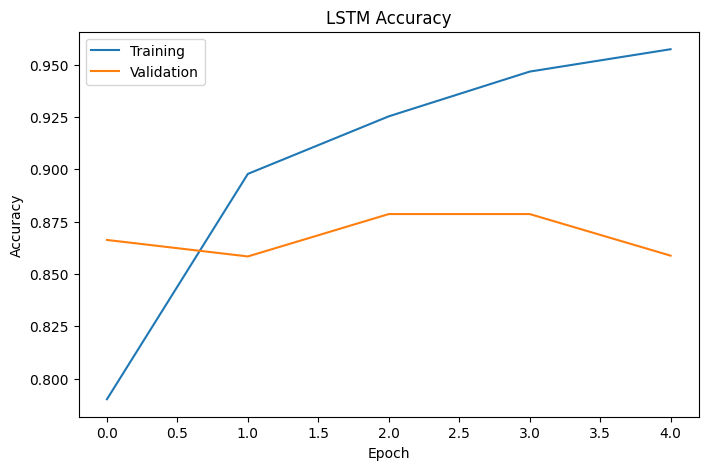

In [28]:
#Ploting training and validation accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend([
    "Training",
    "Validation"
])
plt.show()

In [29]:
# Prediction of sentiment
prediction = model.predict(X_test)
prediction = (prediction > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step


In [30]:
#Classification report
print(classification_report(
    y_test,
    prediction
))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      5000
           1       0.86      0.86      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



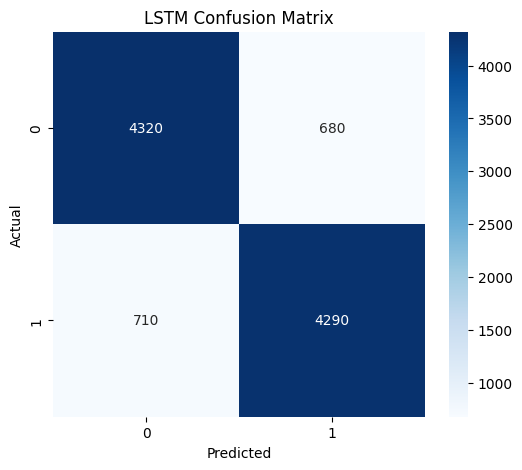

In [31]:
CM = confusion_matrix(
    y_test,
    prediction
)
plt.figure(figsize=(6,5))
sns.heatmap(
    CM,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")
plt.show()

In [32]:
model.save("LSTM_sentiment_model.keras")
print("Model saved successfully.") #Saving the model

Model saved successfully.
